In [1]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tiktoken
from sklearn.model_selection import train_test_split

# LOAD DATA

## SAFRAN PROJECT DATASET

**The ASRS data loaded below are the final clean dataset used to feed the model => They have been splited in 10 fold already with the final laebls**. 

We import these data in this notebook for (re)-exploration 

In [2]:
train_data = pd.read_parquet(
    "../data/03_final/final_safran_asrs_14label_fit_10fold_seed_4294967295.parquet"
)
test_data = pd.read_parquet("../data/03_final/final_safran_asrs_14label_test.parquet")

In [3]:
train_data.head()

,acn,narrative,anomaly,fold
0,1299097,The flight came over descending to FL240 flyin...,Deviation/Discrepancy - Procedural ; Deviation...,3.0
1,1299098,I was sequencing multiple arrivals to ZZZ; 2 r...,Conflict ; Deviation/Discrepancy - Procedural ...,2.0
2,1299106,An aircraft entered New York's non-radar airsp...,Airspace Violation ; Deviation/Discrepancy - P...,7.0
3,1299250,We were cruising at FL360; in cirrus type clou...,Deviation/Discrepancy - Procedural ; Flight De...,4.0
4,1299290,Bird strike at approximately 300-400 AGL durin...,Inflight Event/Encounter ; Aircraft Equipment,0.0


In [4]:
test_data.head()

,acn,narrative,anomaly
13,1299665,Weather scattered about 4;500 feet could not s...,Deviation/Discrepancy - Procedural ; Deviation...
33,1300042,As we approached Runway 8 in DEN for takeoff; ...,Inflight Event/Encounter ; ATC Issue
49,1300383,Upon being seated in the hotel van; the van dr...,Airspace Violation ; Deviation/Discrepancy - P...
70,1300774,Cleared to taxi into position and hold Runway ...,Conflict ; Ground Incursion ; ATC Issue ; Devi...
72,1300807,During a training flight; I was making routine...,Conflict ; Deviation/Discrepancy - Procedural


In [5]:
(train_data.shape, test_data.shape)

((89724, 4), (10023, 3))

## 1988 - 2025 ASRS's DATA (some reports may be missing due to processing)

In [6]:
asrs = pd.read_parquet("../data/01_primary/asrs_data_primary.parquet")

Let's merge `asrs` dataframe with `safran` dataframes to get raw unprocessed labels.

In [7]:
train_acn = train_data.acn.tolist()
test_acn = test_data.acn.tolist()
full_acn = train_acn + test_acn

In [8]:
train_data = asrs.loc[asrs.acn.isin(train_acn)][["acn", "narrative", "anomaly"]]
test_data = asrs.loc[asrs.acn.isin(test_acn)][["acn", "narrative", "anomaly"]]
full_data = asrs.loc[asrs.acn.isin(full_acn)][["acn", "narrative", "anomaly"]]

In [9]:
(train_data.shape, test_data.shape)

((89724, 3), (10023, 3))

In [10]:
train_data.head()

,acn,narrative,anomaly
0,1299097,The flight came over descending to FL240 flyin...,Deviation - Altitude Crossing Restriction Not ...
1,1299098,I was sequencing multiple arrivals to ZZZ; 2 r...,Conflict Airborne Conflict; Deviation - Speed ...
2,1299106,An aircraft entered New York's non-radar airsp...,Airspace Violation All Types; Deviation / Disc...
3,1299250,We were cruising at FL360; in cirrus type clou...,Deviation - Altitude Excursion From Assigned A...
4,1299290,Bird strike at approximately 300-400 AGL durin...,Aircraft Equipment Problem Less Severe; Inflig...


In [11]:
test_data.head()

,acn,narrative,anomaly
13,1299665,Weather scattered about 4;500 feet could not s...,Deviation - Altitude Excursion From Assigned A...
33,1300042,As we approached Runway 8 in DEN for takeoff; ...,ATC Issue All Types; Inflight Event / Encounte...
49,1300383,Upon being seated in the hotel van; the van dr...,Airspace Violation All Types; Deviation / Disc...
70,1300774,Cleared to taxi into position and hold Runway ...,ATC Issue All Types; Conflict Ground Conflict;...
72,1300807,During a training flight; I was making routine...,Conflict Airborne Conflict; Deviation / Discre...


Let load the taxonomy extracted from the taxonomy pdf files

In [12]:
with open("../data/01_primary/taxonomy.json", "r") as f:
    taxonomy = json.load(f)
print(taxonomy)

{'Aircraft Equipment': ['Critical', 'Less Severe'], 'Airspace Violation': ['All Types'], 'ATC Issues': ['All Types'], 'Flight Deck/Cabin/Aircraft Event': ['Illness / Injury', 'Passenger Electronic Device', 'Passenger Misconduct', 'Smoke / Fire / Fumes / Odor', 'Other / Unknown'], 'Conflict': ['NMAC', 'Airborne Conflict', 'Ground Conflict, Critical', 'Ground Conflict, Less Severe'], 'Deviation - Altitude': ['Crossing Restriction Not Met', 'Excursion from Assigned Altitude', 'Overshoot', 'Undershoot'], 'Deviation - Speed': ['All Types'], 'Deviation - Track/Heading': ['All Types'], 'Deviation / Discrepancy - Procedural': ['Clearance', 'FAR', 'Hazardous Material Violation', 'Landing without Clearance', 'Maintenance', 'MEL / CDL', 'Published Material/Policy', 'Security', 'Unauthorized Flight Operations (UAS)', 'Weight and Balance', 'Other / Unknown'], 'Ground Excursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Incursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Event/Encounter': ['Aircraft', 

# FUNC

In [13]:
def get_cat(taxonomy, exclude, include):
    return [cat for cat in taxonomy.keys() if cat not in exclude] + include


def re_pattern(categories):
    escaped_categories = [
        re.escape(term.strip().replace(" / ", "/")) for term in categories
    ]
    return re.compile(r"^(" + "|".join(escaped_categories) + r")")

In [14]:
def get_categories(
    text: "str", pattern: "re.Pattern", mode: "str" = "taxonomy", exclude: "list" = None
):
    if mode not in ["all", "unknown", "taxonomy", "other"]:
        raise ValueError('`mode` value must be in ["all", "unknown", "taxonomy"]')
    if text is not None:
        split = text.split(";")
        anomalies = []
        for a in split:
            label = a.strip().replace(" / ", "/")
            out = pattern.findall(label)
            if out == [] and mode != "taxonomy":
                if mode == "all":
                    out = [label]
                elif mode == "unknown":
                    out = ["Unknown"]
                elif mode == "other":
                    out = ["Other"]
            if isinstance(exclude, list) and out != []:
                out = [cat for cat in out if cat not in exclude]
            anomalies.extend(out)
        return " ; ".join(set(anomalies))

In [15]:
def one_hot(mapper, text: "str | None" = None):
    if text is None:
        return text
    num_labels = [0] * len(mapper)
    labels = [label.strip().replace(" / ", "/") for label in text.split(";")]
    for label in labels:
        num_labels[mapper[label]] = 1
    return num_labels

In [16]:
def get_onehot_mapping(categories, n):
    one_hot_mapping = dict(zip(sorted(categories), range(0, n)))
    one_hot_mapping = {
        k.strip().replace(" / ", "/"): v for (k, v) in one_hot_mapping.items()
    }
    return one_hot_mapping

In [17]:
def get_occurences(serie: "pd.Series"):
    occurences = []
    none_counter = 0
    for item in serie.to_list():
        if item is not None:
            occurences.extend([term.strip() for term in item.split(";")])
        else:
            none_counter += 1
    counter = Counter(occurences)
    return counter, none_counter

In [18]:
def get_cooc_mat(series, mapping):
    one_hot_anomalies = series.apply(lambda text: one_hot(mapping, text))
    labels = np.array([l for l in one_hot_anomalies.values])
    cooc = ((labels.T @ labels) / labels.shape[0]) * 100
    mask = np.triu(np.ones_like(cooc, dtype=bool), k=1)
    return cooc, mask, labels

In [19]:
def plot_cooc(cooc, mask, labels, **kwargs):
    plt.figure(figsize=kwargs["figsize"])

    ax = sns.heatmap(
        cooc,
        yticklabels=labels,
        xticklabels=labels,
        annot=kwargs["annot"],
        cmap=kwargs["cmap"],
        mask=mask,
        annot_kws={"size": kwargs["annot_kws"]},
    )

    ax.set_title(kwargs["title"], fontsize=10)

    ax.tick_params(axis="x", labelsize=kwargs["x_labelsize"])
    ax.tick_params(axis="y", labelsize=kwargs["y_labelsize"])

    plt.tight_layout()
    plt.show()

# EXPLORE DATA

In [20]:
full_data.head()

,acn,narrative,anomaly
0,1299097,The flight came over descending to FL240 flyin...,Deviation - Altitude Crossing Restriction Not ...
1,1299098,I was sequencing multiple arrivals to ZZZ; 2 r...,Conflict Airborne Conflict; Deviation - Speed ...
2,1299106,An aircraft entered New York's non-radar airsp...,Airspace Violation All Types; Deviation / Disc...
3,1299250,We were cruising at FL360; in cirrus type clou...,Deviation - Altitude Excursion From Assigned A...
4,1299290,Bird strike at approximately 300-400 AGL durin...,Aircraft Equipment Problem Less Severe; Inflig...


In [21]:
taxonomy_categories = get_cat(taxonomy, ["ATC Issues"], ["ATC Issue", "Unknown"])
pattern = re_pattern(taxonomy_categories)

print("Taxonomy : ", taxonomy)
print("Taxonomy categories : ", taxonomy_categories)
print("Re Pattern : ", pattern)

Taxonomy :  {'Aircraft Equipment': ['Critical', 'Less Severe'], 'Airspace Violation': ['All Types'], 'ATC Issues': ['All Types'], 'Flight Deck/Cabin/Aircraft Event': ['Illness / Injury', 'Passenger Electronic Device', 'Passenger Misconduct', 'Smoke / Fire / Fumes / Odor', 'Other / Unknown'], 'Conflict': ['NMAC', 'Airborne Conflict', 'Ground Conflict, Critical', 'Ground Conflict, Less Severe'], 'Deviation - Altitude': ['Crossing Restriction Not Met', 'Excursion from Assigned Altitude', 'Overshoot', 'Undershoot'], 'Deviation - Speed': ['All Types'], 'Deviation - Track/Heading': ['All Types'], 'Deviation / Discrepancy - Procedural': ['Clearance', 'FAR', 'Hazardous Material Violation', 'Landing without Clearance', 'Maintenance', 'MEL / CDL', 'Published Material/Policy', 'Security', 'Unauthorized Flight Operations (UAS)', 'Weight and Balance', 'Other / Unknown'], 'Ground Excursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Incursion': ['Ramp', 'Runway', 'Taxiway'], 'Ground Event/Encounter': [

## EXPLORE LABELS

## FULL DATA

In [22]:
all_anomalies = full_data.anomaly.apply(
    lambda t: get_categories(text=t, pattern=pattern, mode="all")
)  # Get All label in the dataset

Let display all labels in the dataset

In [23]:
all_counter, none_counter = get_occurences(all_anomalies)
print("# observations sans labels : ", none_counter)
print("nombre de labels unique :", len(all_counter))
print(all_counter)

# observations sans labels :  0
nombre de labels unique : 216
Counter({'Deviation/Discrepancy - Procedural': 60737, 'Aircraft Equipment': 40029, 'Inflight Event/Encounter': 18412, 'Conflict': 17990, 'ATC Issue': 17371, 'Deviation - Altitude': 9223, 'Deviation - Track/Heading': 8700, 'Ground Event/Encounter': 7586, 'Flight Deck/Cabin/Aircraft Event': 7557, 'Other': 7339, 'Ground Incursion': 5419, 'Airspace Violation': 4210, 'Deviation - Speed': 2845, 'Critical': 2516, 'Less Severe': 2450, 'Ground Excursion': 2260, 'No Specific Anomaly Occurred': 496, 'CRM': 22, 'HEARBACK': 7, 'Hearback': 5, 'HEARBACK. CTLR HANDLING': 3, 'READBACK': 3, 'CRM.': 3, 'CTLR HANDLING': 2, 'Smoke in Cockpit. Acft Had Electrical Fire.': 1, 'Programming Protocol Not Followed': 1, 'Clrnc': 1, 'Data Link': 1, 'Interp': 1, 'Hearback. Acft Not TCAS Equiped': 1, 'Txwy Signage': 1, 'Ctlr Handling': 1, 'Covered With Ice and Snow': 1, 'Acft Behind Had Visual With Them': 1, 'High N2 Vibration': 1, 'But Acft Was Too Fast T

216 labels in the whole dataset so it makes sense to gather them in a new category/label `Unknown`

In [24]:
unk_anomalies = full_data.anomaly.apply(
    lambda t: get_categories(text=t, pattern=pattern, mode="unknown")
)  # Gather unknown labels in Unknown

In [25]:
unk_counter, none_counter = get_occurences(unk_anomalies)
print("# observations sans labels : ", none_counter)
print("nombre de labels unique :", len(unk_counter))
print(unk_counter)

# observations sans labels :  0
nombre de labels unique : 16
Counter({'Deviation/Discrepancy - Procedural': 60737, 'Aircraft Equipment': 40029, 'Inflight Event/Encounter': 18412, 'Conflict': 17990, 'ATC Issue': 17371, 'Deviation - Altitude': 9223, 'Deviation - Track/Heading': 8700, 'Ground Event/Encounter': 7586, 'Flight Deck/Cabin/Aircraft Event': 7557, 'Other': 7339, 'Ground Incursion': 5419, 'Unknown': 5155, 'Airspace Violation': 4210, 'Deviation - Speed': 2845, 'Ground Excursion': 2260, 'No Specific Anomaly Occurred': 496})


But it might be better to Gather all the Unknown labels in the `Other` label as it has a `write in` sub-category relevant with a free textbox for not commons labels that are not in the taxonomy.

In [26]:
other_anomalies = full_data.anomaly.apply(
    lambda t: get_categories(text=t, pattern=pattern, mode="other")
)  # Gather unknown labels with Other

In [27]:
o_counter, none_counter = get_occurences(other_anomalies)
print("# observations sans labels : ", none_counter)
print("nombre de labels unique :", len(o_counter))
print(o_counter)

# observations sans labels :  0
nombre de labels unique : 15
Counter({'Deviation/Discrepancy - Procedural': 60737, 'Aircraft Equipment': 40029, 'Inflight Event/Encounter': 18412, 'Conflict': 17990, 'ATC Issue': 17371, 'Other': 11865, 'Deviation - Altitude': 9223, 'Deviation - Track/Heading': 8700, 'Ground Event/Encounter': 7586, 'Flight Deck/Cabin/Aircraft Event': 7557, 'Ground Incursion': 5419, 'Airspace Violation': 4210, 'Deviation - Speed': 2845, 'Ground Excursion': 2260, 'No Specific Anomaly Occurred': 496})


### COOCCURENCE MATRICES

In [28]:
full_data.isna().sum()

acn          0
narrative    0
anomaly      0
dtype: int64

#### W/ Unknown

In [29]:
unk_one_hot = get_onehot_mapping(taxonomy_categories, 16)
print(unk_one_hot)

{'ATC Issue': 0, 'Aircraft Equipment': 1, 'Airspace Violation': 2, 'Conflict': 3, 'Deviation - Altitude': 4, 'Deviation - Speed': 5, 'Deviation - Track/Heading': 6, 'Deviation/Discrepancy - Procedural': 7, 'Flight Deck/Cabin/Aircraft Event': 8, 'Ground Event/Encounter': 9, 'Ground Excursion': 10, 'Ground Incursion': 11, 'Inflight Event/Encounter': 12, 'No Specific Anomaly Occurred': 13, 'Other': 14, 'Unknown': 15}


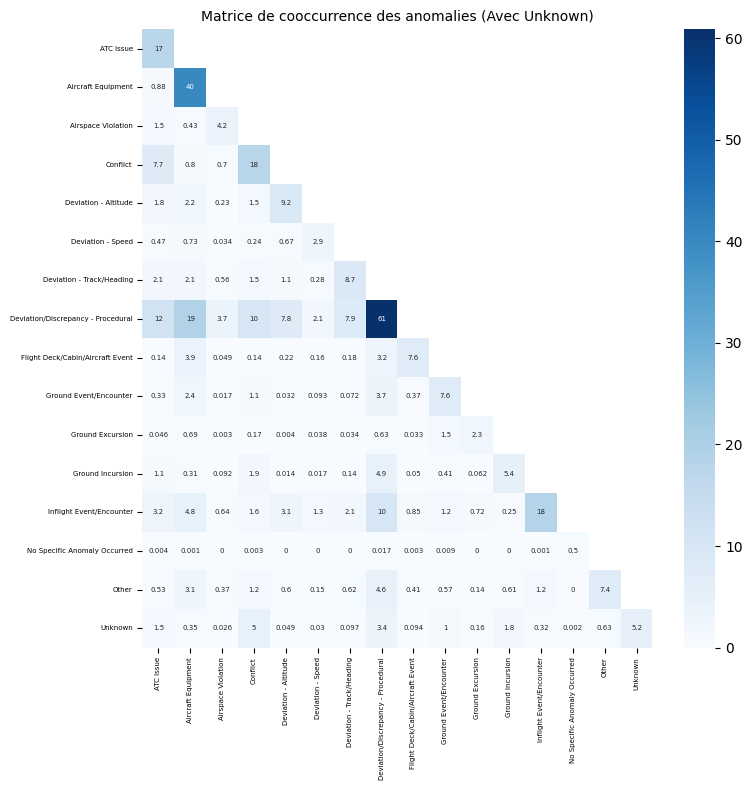

In [30]:
cooc, mask, _ = get_cooc_mat(unk_anomalies, unk_one_hot)
plot_cooc(
    cooc,
    mask,
    unk_one_hot.keys(),
    figsize=(8, 8),
    annot=True,
    cmap="Blues",
    annot_kws=5,
    title="Matrice de cooccurrence des anomalies (Avec Unknown)",
    x_labelsize=5,
    y_labelsize=5,
)

#### SANS Unknown

In [31]:
o_one_hot = get_onehot_mapping(taxonomy_categories, 15)
print(o_one_hot)

{'ATC Issue': 0, 'Aircraft Equipment': 1, 'Airspace Violation': 2, 'Conflict': 3, 'Deviation - Altitude': 4, 'Deviation - Speed': 5, 'Deviation - Track/Heading': 6, 'Deviation/Discrepancy - Procedural': 7, 'Flight Deck/Cabin/Aircraft Event': 8, 'Ground Event/Encounter': 9, 'Ground Excursion': 10, 'Ground Incursion': 11, 'Inflight Event/Encounter': 12, 'No Specific Anomaly Occurred': 13, 'Other': 14}


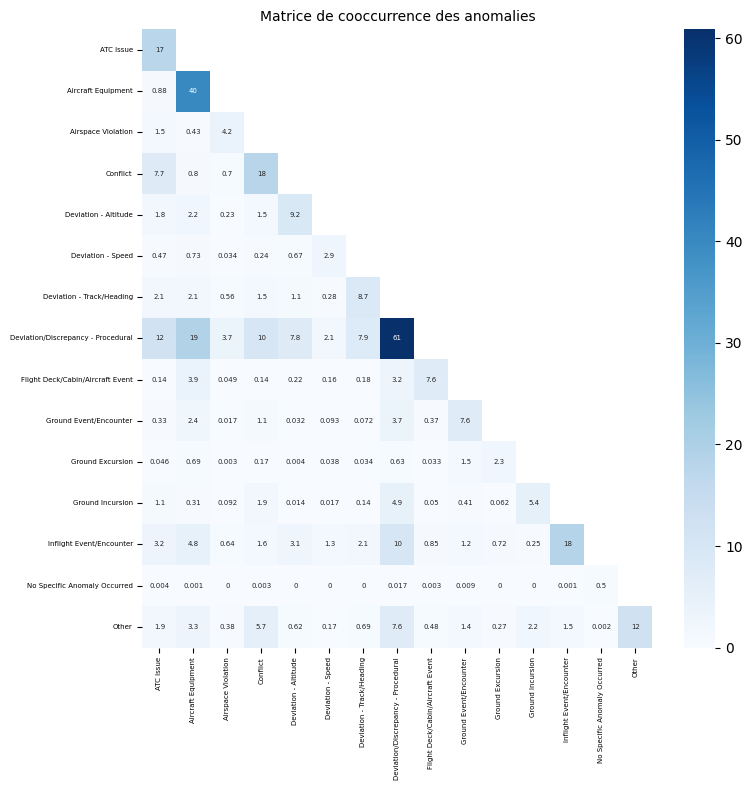

In [32]:
cooc, mask, labels = get_cooc_mat(other_anomalies, o_one_hot)
plot_cooc(
    cooc,
    mask,
    o_one_hot.keys(),
    figsize=(8, 8),
    annot=True,
    cmap="Blues",
    annot_kws=5,
    title="Matrice de cooccurrence des anomalies",
    x_labelsize=5,
    y_labelsize=5,
)

A cet stade il paraît judicieux d'exlure la catégorie `Other` de l'ensemble des labels à prédire car importante en terme d'occurence mais en même temps très hétérogène. Cette catégorie cooapparaît régulièrement avec d'autres labels dans des proportions importantes, ce qui confirme le fait qu'il s'agit dans la grande majorité des cas de nouveaux labels distinct de ceux de la taxonomie d'autant plus que c'est une labélisation confirmée par les analystes experts qui ont une normalement une excellente maîtrise des labels de la taxonomie. `Devons nous exclure les observations labéllisées Other ?`

let compute how many time, `Other` occurs `lonely`

In [33]:
only_other_bools = (np.sum(labels, axis=1) == 1) & (labels[:, -1] == 1)
print(
    "# rapport où `Other` apparaît seul : ",
    len(np.where((np.sum(labels, axis=1) == 1) & (labels[:, -1] == 1))[0]),
)

# rapport où `Other` apparaît seul :  15


Il 15 rapport où `Other` apparaît seul. Si nous décidons d'exclure `Other` de l'ensemble des labels à prédire il n'est d'aucune utilité de conserver ces rapport dans notre dataset.

In [34]:
full_data.loc[only_other_bools]

,acn,narrative,anomaly
45302,581790,WE WERE CLRED FOR TKOF ON RWY 27. AFTER ACKNOW...,Other Intersecting Rwy Conflict
54032,727613,WE HAD STARTED OUR TKOF ROLL FROM ORD RWY 32L ...,Other ATC Issued Abort
68088,810169,I WAS WORKING LCL CTL W. ACFT X HAD BEEN CLRED...,Other ATC Issued GAR
83794,738550,I CAME TO WORK IN THE AFTERNOON TO LEARN THAT ...,Other Rocket Conflict Activity
90862,676034,ACR X WAS INBOUND TO CVG. I DSNDED ACFT FROM 1...,Other Conflict Alert On False Target
91040,677324,AFTER LNDG ON RWY 19R LAS; HVY WITH SLIGHT TAI...,Other Confusing/Conflicting Taxi Instructions
101621,709815,I FEEL SAFETY OF FLT WAS COMPROMISED WITH THE ...,Other Security Conflict
102152,713689,I WAS WORKING THE E ARR/DEP POS COMBINED DURIN...,Other False Conflict Alert
102457,715237,I WAS WORKING FINAL W (ARF) IN A S CONFIGN. ME...,Other Continous Conflict Alert
102998,718157,FO UNFIT FOR DUTY. UPON CHK-IN I MET MY SCHEDU...,Other FLT Crew Conflict; Personal


On pourrait analyser les rapport et leur attribuer des catégories mais ce serait chronophage et sans grand intérêt étant donné que nous avons beacoup de rapports dans les catégories qui ont un lien avec les labels de ce groupe.

#### Process no specific anomaly occuring with other categories

In [35]:
not_only_nsao_bool = (np.sum(labels, axis=1) > 1) & (labels[:, -2] == 1)
print(
    "# rapport où `NSAO` n'apparaît pas seul : ",
    len(np.where((np.sum(labels, axis=1) > 1) & (labels[:, -2] == 1))[0]),
)

# rapport où `NSAO` n'apparaît pas seul :  24


In [36]:
full_data.loc[not_only_nsao_bool]

,acn,narrative,anomaly
126186,598660,ON OCT/THU/03; ACFT WAS IN MAINT FOR A C-CHK. ...,Deviation / Discrepancy - Procedural Published...
126198,598690,I DEPARTED FROM 4N1 ARPT AROUND XA30 ON NOV/SA...,Deviation / Discrepancy - Procedural Published...
126237,598823,ON A FLT FROM MSP TO GEG; AS THE PNF; I FAILED...,Deviation / Discrepancy - Procedural Published...
126246,598853,I WAS RETURNING TO HOME FIELD IN MY EXPERIMENT...,Flight Deck / Cabin / Aircraft Event Other / U...
126370,599436,ACFT X WAS A SPECIAL VISIT FOR 178 BULKHEAD IN...,Aircraft Equipment Problem Critical; Deviation...
162201,1772488,The ramp light post lights are extremely brigh...,Ground Event / Encounter Ground Equipment Issu...
162270,1773173,Runway 22 in MMPR has a 4 bar PAPI. The trees ...,ATC Issue All Types; Ground Event / Encounter ...
162423,1774773,Following two previous approach attempts into ...,Inflight Event / Encounter Unstabilized Approa...
162464,1775343,After landing in ZZZZ airport personnel took o...,Deviation / Discrepancy - Procedural Published...
162468,1775378,I have witnessed a potential for aircraft spoi...,Deviation / Discrepancy - Procedural Maintenan...


24 rapport sont concernés pas NSAO x autres labels. Sans rentrer de le détail du contenu de chaque rapport, les rapports de ce groupe se labélisé NSAO pour se conformer à la logique de cette catégorie.

In [37]:
np.where(not_only_nsao_bool == True)

(array([35345, 35354, 35385, 35392, 35476, 52311, 52370, 52505, 52543,
        52547, 52555, 52599, 52607, 52625, 52656, 52674, 52753, 52797,
        52832, 52857, 52878, 52898, 52903, 52944]),)

#### Relabel Not only NSAO

In [38]:
acn_nsao = full_data.loc[not_only_nsao_bool, "acn"].values

In [39]:
train_data.loc[train_data.acn.isin(acn_nsao), "anomaly"] = train_data.loc[
    train_data.acn.isin(acn_nsao), "anomaly"
].apply(lambda x: "No Specific Anomaly Occurred")

In [40]:
train_data.loc[train_data.acn.isin(acn_nsao), "anomaly"]

126186    No Specific Anomaly Occurred
126198    No Specific Anomaly Occurred
126237    No Specific Anomaly Occurred
126246    No Specific Anomaly Occurred
126370    No Specific Anomaly Occurred
162201    No Specific Anomaly Occurred
162270    No Specific Anomaly Occurred
162423    No Specific Anomaly Occurred
162464    No Specific Anomaly Occurred
162476    No Specific Anomaly Occurred
162532    No Specific Anomaly Occurred
162541    No Specific Anomaly Occurred
162561    No Specific Anomaly Occurred
162596    No Specific Anomaly Occurred
162619    No Specific Anomaly Occurred
162709    No Specific Anomaly Occurred
162759    No Specific Anomaly Occurred
162801    No Specific Anomaly Occurred
162831    No Specific Anomaly Occurred
162853    No Specific Anomaly Occurred
162875    No Specific Anomaly Occurred
162880    No Specific Anomaly Occurred
162932    No Specific Anomaly Occurred
Name: anomaly, dtype: object

Le Même traitement n'est pas appliqué à `Test` pour challenger la précision du modèle (prédire uniquement NSAO seul)

#### Clean out Only others

In [41]:
acn_only_other = full_data.loc[only_other_bools].acn.values

In [42]:
train_data = train_data.loc[~train_data.acn.isin(acn_only_other)]

In [43]:
train_data.shape

(89709, 3)

Les 15 rapport étaient donc de l'ensemble `Train`. Dans tous les cas il n'était pas prévu d'exclure les only other de l'ensemble de test pour challenger la précision du modèle.

# EXPLORATION DES DEUX ENSEMBLES TRAIN ET TEST PRIS SEPAREMENT

In [44]:
taxonomy_categories = get_cat(taxonomy, ["ATC Issues", "Other"], ["ATC Issue"])
mapping = get_onehot_mapping(taxonomy_categories, n=14)  # excludes Others and Unknown
print(mapping)

{'ATC Issue': 0, 'Aircraft Equipment': 1, 'Airspace Violation': 2, 'Conflict': 3, 'Deviation - Altitude': 4, 'Deviation - Speed': 5, 'Deviation - Track/Heading': 6, 'Deviation/Discrepancy - Procedural': 7, 'Flight Deck/Cabin/Aircraft Event': 8, 'Ground Event/Encounter': 9, 'Ground Excursion': 10, 'Ground Incursion': 11, 'Inflight Event/Encounter': 12, 'No Specific Anomaly Occurred': 13}


In [45]:
train_anomalies = train_data.anomaly.apply(
    lambda x: get_categories(x, pattern, exclude=["Other"])
)
test_anomalies = test_data.anomaly.apply(
    lambda x: get_categories(x, pattern, exclude=["Other"])
)

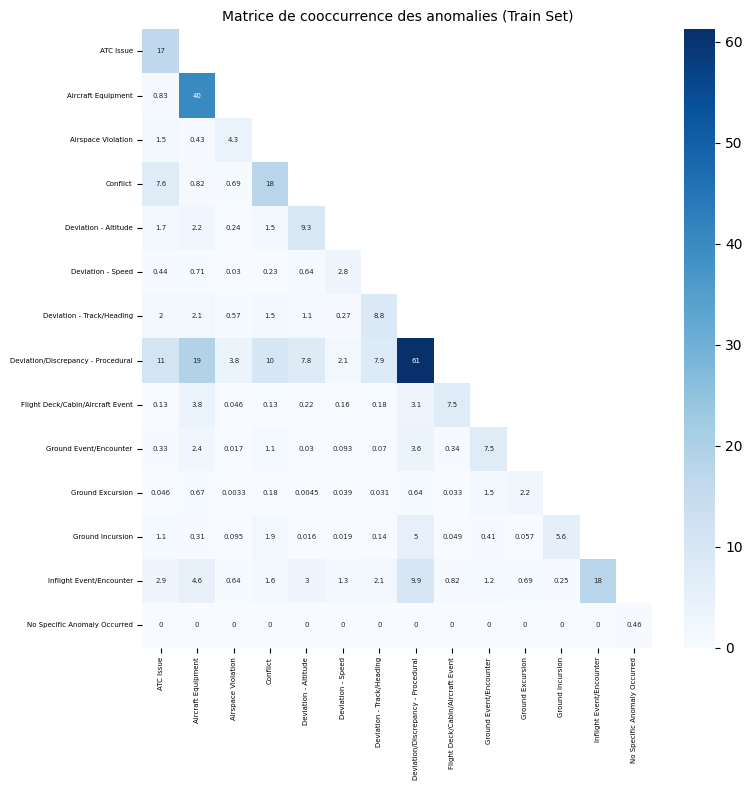

In [46]:
train_cooc, mask, labels = get_cooc_mat(train_anomalies, mapping)
plot_cooc(
    train_cooc,
    mask,
    mapping.keys(),
    figsize=(8, 8),
    annot=True,
    cmap="Blues",
    annot_kws=5,
    title="Matrice de cooccurrence des anomalies (Train Set)",
    x_labelsize=5,
    y_labelsize=5,
)

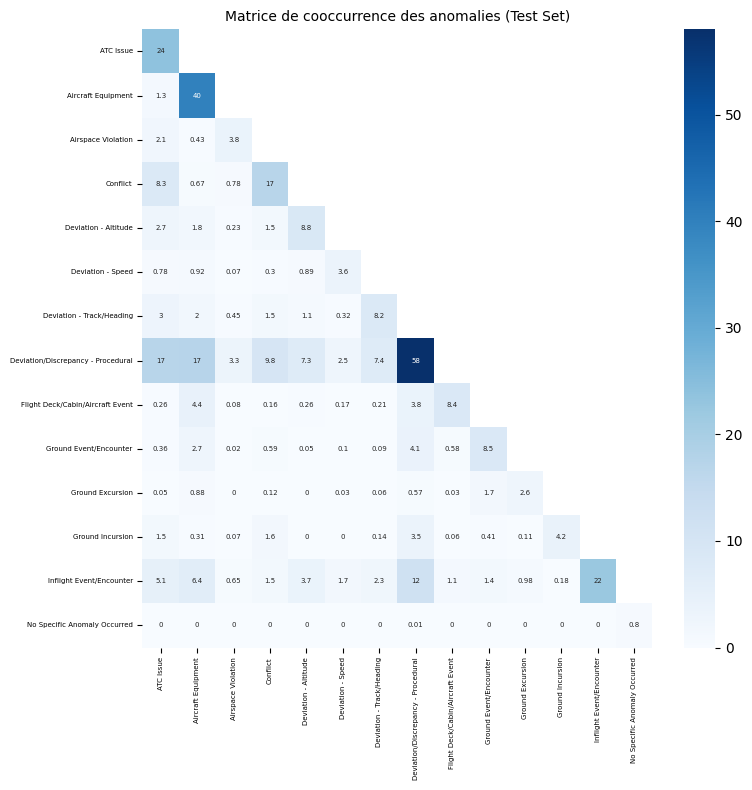

In [47]:
test_cooc, mask, labels = get_cooc_mat(test_anomalies, mapping)
plot_cooc(
    test_cooc,
    mask,
    mapping.keys(),
    figsize=(8, 8),
    annot=True,
    cmap="Blues",
    annot_kws=5,
    title="Matrice de cooccurrence des anomalies (Test Set)",
    x_labelsize=5,
    y_labelsize=5,
)

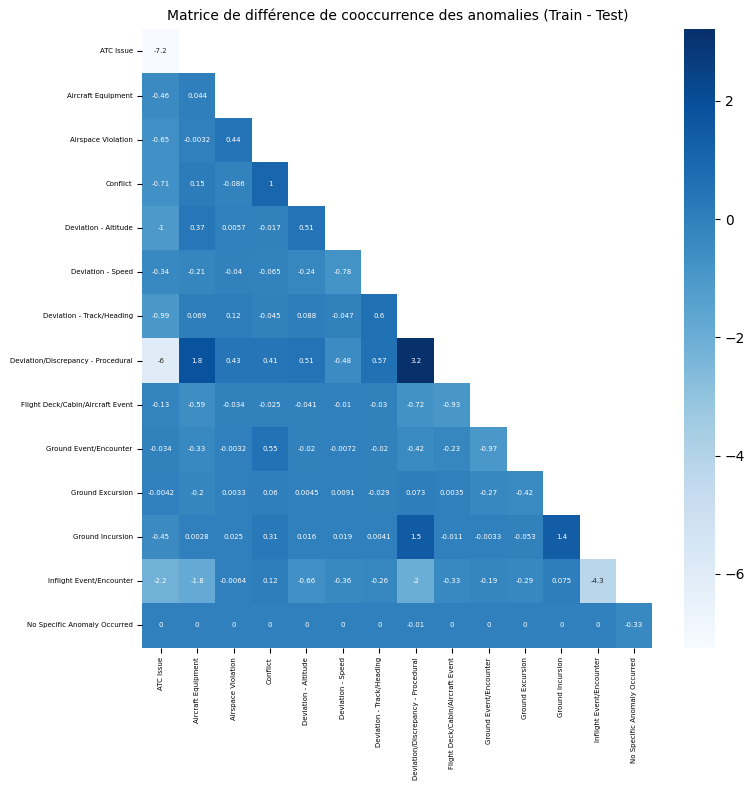

In [48]:
plot_cooc(
    train_cooc - test_cooc,
    mask,
    mapping.keys(),
    figsize=(8, 8),
    annot=True,
    cmap="Blues",
    annot_kws=5,
    title="Matrice de différence de cooccurrence des anomalies (Train - Test)",
    x_labelsize=5,
    y_labelsize=5,
)

Les catégories d'anomalies sont quasiment distribué pareillement. les classes sont déséquilibrées dans les deux ensembles. Les proportions de cooccurences conservent le même ordre presque tout le temps. les mêmes tendances

In [49]:
train_oc, _ = get_occurences(train_anomalies)
test_oc, _ = get_occurences(test_anomalies)

In [50]:
test_oc + train_oc

Counter({'Deviation/Discrepancy - Procedural': 60723,
         'Aircraft Equipment': 40030,
         'Inflight Event/Encounter': 18412,
         'Conflict': 17987,
         'ATC Issue': 17368,
         'Deviation - Altitude': 9223,
         'Deviation - Track/Heading': 8701,
         'Ground Event/Encounter': 7577,
         'Flight Deck/Cabin/Aircraft Event': 7555,
         'Ground Incursion': 5419,
         'Airspace Violation': 4210,
         'Deviation - Speed': 2845,
         'Ground Excursion': 2260,
         'No Specific Anomaly Occurred': 496})

In [51]:
counters = zip([train_oc, test_oc], ["Train", "Test"])

In [52]:
data = [
    pd.DataFrame(
        {
            "anomaly": counter.keys(),
            "count": counter.values(),
            "split": [name] * len(counter),
        }
    )
    for (counter, name) in counters
]
data = pd.concat(data).reset_index()

In [53]:
data.loc[data.split == "Train", "count"] = (
    (data.loc[data.split == "Train", "count"] / len(train_data))
) * 100
data.loc[data.split == "Test", "count"] = (
    (data.loc[data.split == "Test", "count"] / len(test_data))
) * 100
data.loc[data.split == "Train + Test", "count"] = (
    (
        data.loc[data.split == "Train + Test", "count"]
        / (len(test_data) + len(train_data))
    )
) * 100

/tmp/ipykernel_19080/1067372075.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[61.20902028  9.29895551 18.1386483   2.77452652  8.78507173  4.26601567
 18.03386505  7.48196948 40.14201474  7.49980492 16.68617419  0.46372159
  5.57357679  2.22385714]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.split == 'Train', 'count']= ((data.loc[data.split == 'Train', 'count'] / len(train_data))) * 100


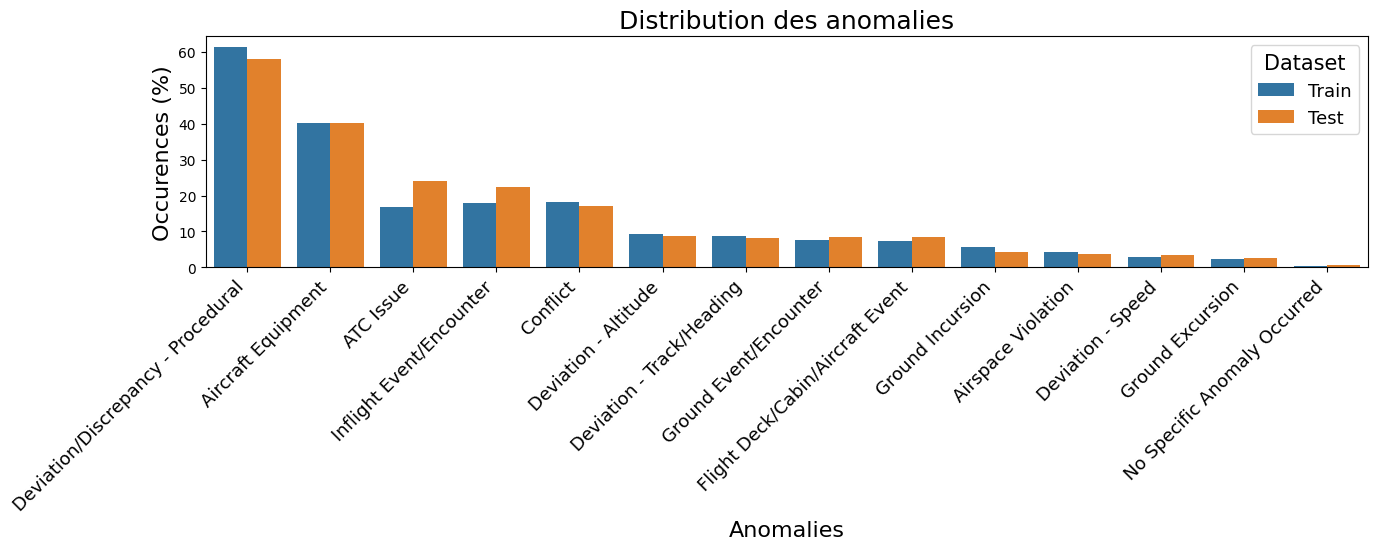

In [54]:
plt.figure(figsize=(15, 3))
sns.barplot(
    data=data.sort_values(by=["count", "split"], ascending=False),
    hue="split",
    x="anomaly",
    y="count",
)
plt.xticks(rotation=45, ha="right", fontsize=13)  # or try 90 for vertical
plt.xlabel("Anomalies", fontsize=16)
plt.ylabel("Occurences (%)", fontsize=16)
plt.title("Distribution des anomalies", fontsize=18)
plt.legend(title="Dataset", title_fontsize=15, fontsize=13)
plt.show()

RAS, classes équilibrées.

## EXPLORE tokens length

In [55]:
tiktokenizer = tiktoken.get_encoding("cl100k_base")

In [56]:
train_tk_count = [
    len(tiktokenizer.encode(narrative)) for narrative in train_data.narrative.tolist()
]
test_tk_count = [
    len(tiktokenizer.encode(narrative)) for narrative in test_data.narrative.tolist()
]

In [57]:
counters = zip(
    [train_tk_count, test_tk_count],
    ["Train", "Test"],
)

tk_count_data = [
    pd.DataFrame(
        {
            "length": ct,
            "split": [name] * len(ct),
        }
    )
    for (ct, name) in counters
]
tk_data = pd.concat(tk_count_data).reset_index()

In [58]:
tk_data

,index,length,split
0,0,165,Train
1,1,405,Train
2,2,621,Train
3,3,340,Train
4,4,304,Train
...,...,...,...
99727,10018,119,Test
99728,10019,584,Test
99729,10020,166,Test
99730,10021,237,Test


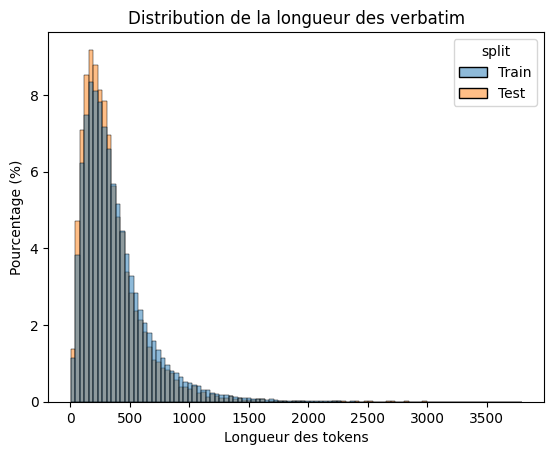

In [59]:
sns.histplot(
    data=tk_data,
    x="length",
    hue="split",
    bins=100,
    stat="percent",
    common_norm=False,
    multiple="layer",
)

plt.title("Distribution de la longueur des verbatim")
plt.xlabel("Longueur des tokens")
plt.ylabel("Pourcentage (%)")
plt.show()

## CREATE FOLD

On va just conserver les fold du début

In [60]:
np.random.seed(4294967295)
train_data.loc[:, "fold"] = np.random.randint(low=0, high=10, size=len(train_data))

## PROCESS FINAL SAFRAN PHASE DATA 

In [61]:
train_data.loc[:, "anomaly"] = train_data.anomaly.apply(
    lambda x: get_categories(x, pattern, exclude=["Other"])
)
test_data.loc[:, "anomaly"] = test_data.anomaly.apply(
    lambda x: get_categories(x, pattern, exclude=["Other"])
)

#### DISPLAY ANOMALY DISTRIBUTION

In [62]:
counters = zip(
    [
        get_occurences(train_data.anomaly.loc[train_data.fold == f])[0]
        for f in range(10)
    ],
    [f"fold-{i}" for i in range(10)],
)

In [63]:
data = [
    pd.DataFrame(
        {
            "anomaly": counter.keys(),
            "count": counter.values(),
            "fold": [fold] * len(counter),
        }
    )
    for (counter, fold) in counters
]
data = pd.concat(data).reset_index()

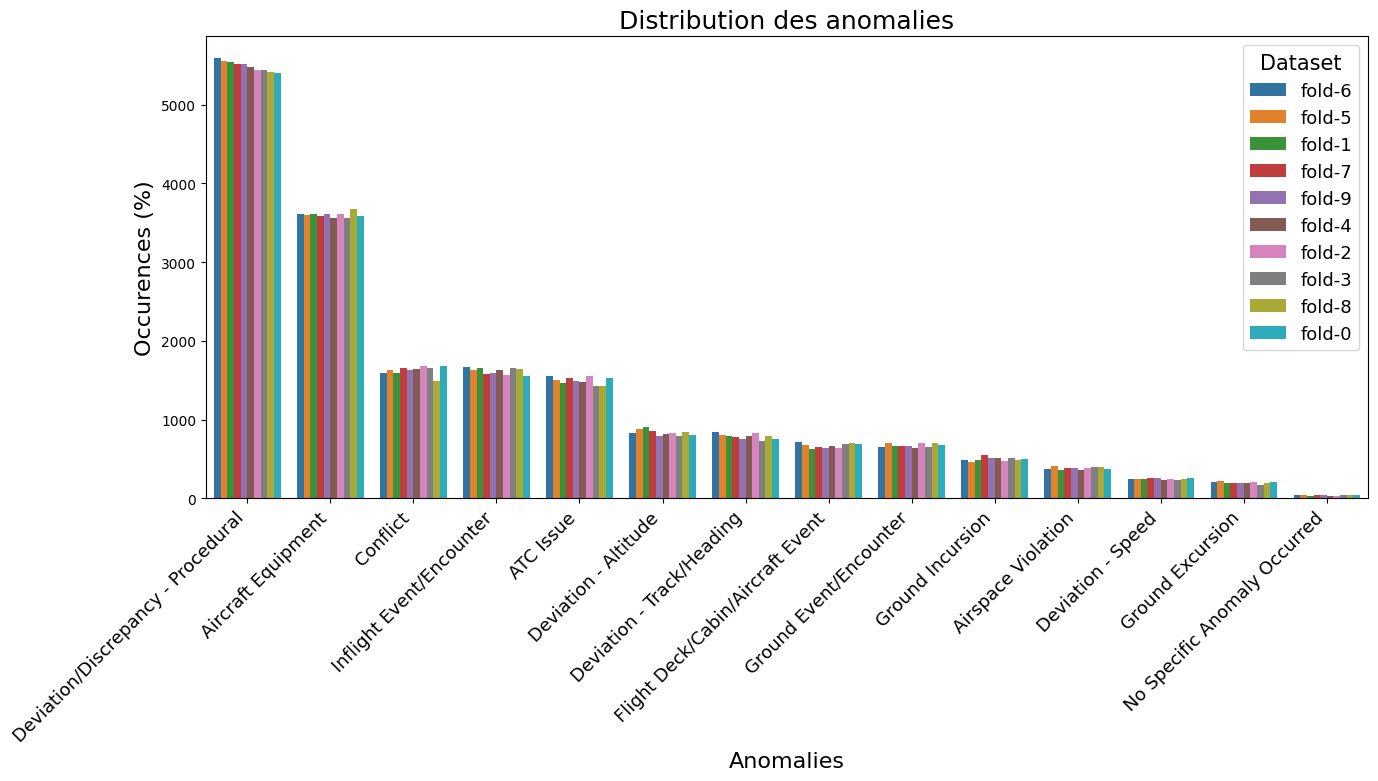

In [64]:
plt.figure(figsize=(15, 6))
sns.barplot(
    data=data.sort_values(by=["count", "fold"], ascending=False),
    hue="fold",
    x="anomaly",
    y="count",
)
plt.xticks(rotation=45, ha="right", fontsize=13)  # or try 90 for vertical
plt.xlabel("Anomalies", fontsize=16)
plt.ylabel("Occurences (%)", fontsize=16)
plt.title("Distribution des anomalies", fontsize=18)
plt.legend(title="Dataset", title_fontsize=15, fontsize=13)
plt.show()

RAS les class sont bien repartis d'un groupe à l'autre.

### EXPORT DES DONNEES

In [ ]:
# train_data.to_parquet("../data/03_final/final_safran_asrs_14label_fit_10fold_seed_4294967295_v2.parquet", index=False)
# test_data.to_parquet("../data/03_final/final_safran_asrs_14label_test_v2.parquet", index=False)

# Entrâinement sans la classe NSAO (VOIR notebook 08)

Les permier résultats avec la première approche montre que le modèle a du mal. avec la denière classe.
Vu la spécificité de notre jeu de données, pas de méthode connu pour de reeéquilibre notre jeu de données. on pourrait:
- récupérer aléatoirement 1000 rapport mais on déplacerait le déséquilibre sur d'autre classe avec un risque de surapprentissage. donc on va faire tu multilabel sur sur 13 classes puis du binaire sur la classe NSAO